In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


shallow = pd.read_csv("shallow_breath_10_individuals.csv")
normal = pd.read_csv("normal_breath_10_individuals.csv")
deep = pd.read_csv("deep_breath_10_individuals.csv")

shallow['label'] = 0
normal['label'] = 1
deep['label'] = 2

df = pd.concat([shallow, normal, deep], ignore_index=True)
df.columns = ['time', 'Vout', 'label']



Q1 = df['Vout'].quantile(0.25)
Q3 = df['Vout'].quantile(0.75)
IQR = Q3 - Q1

df = df[(df['Vout'] >= Q1 - 1.5*IQR) & (df['Vout'] <= Q3 + 1.5*IQR)]


from scipy.signal import butter, filtfilt

def low_pass_filter(signal, cutoff=0.1, fs=1.0, order=3):
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    return filtfilt(b, a, signal)

df['Vout_filtered'] = low_pass_filter(df['Vout'])


def create_windows(data, window_size=50):
    X = []
    y = []

    for i in range(0, len(data) - window_size):
        window = data.iloc[i:i+window_size]

        v = window['Vout_filtered']

        features = [
            v.mean(),
            v.std(),
            v.max(),
            v.min(),
            v.max() - v.min(),        # amplitude
            np.mean(np.diff(v)),      # gradient
            np.var(v),                # variance
        ]

        X.append(features)
        y.append(window['label'].mode()[0])

    return np.array(X), np.array(y)


X, y = create_windows(df, window_size=50)



from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)



from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)



from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    random_state=42
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)


from sklearn.metrics import accuracy_score, classification_report

pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))


Accuracy: 0.9729775662814412
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      2349
           1       0.96      0.95      0.96      1174
           2       0.98      0.97      0.98      2361

    accuracy                           0.97      5884
   macro avg       0.97      0.97      0.97      5884
weighted avg       0.97      0.97      0.97      5884



<Figure size 600x600 with 0 Axes>

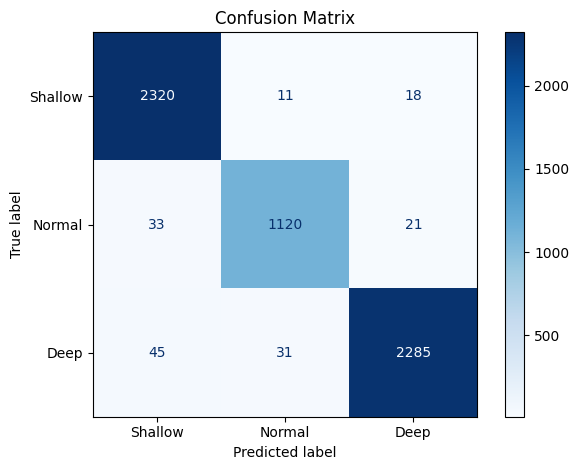

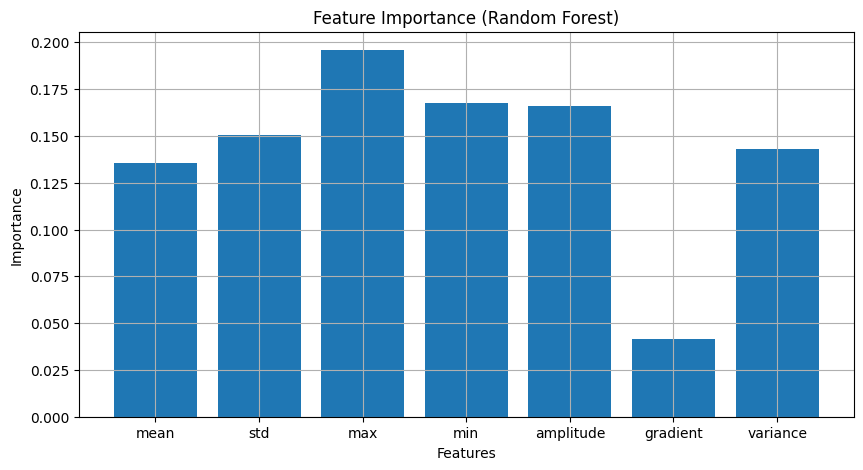

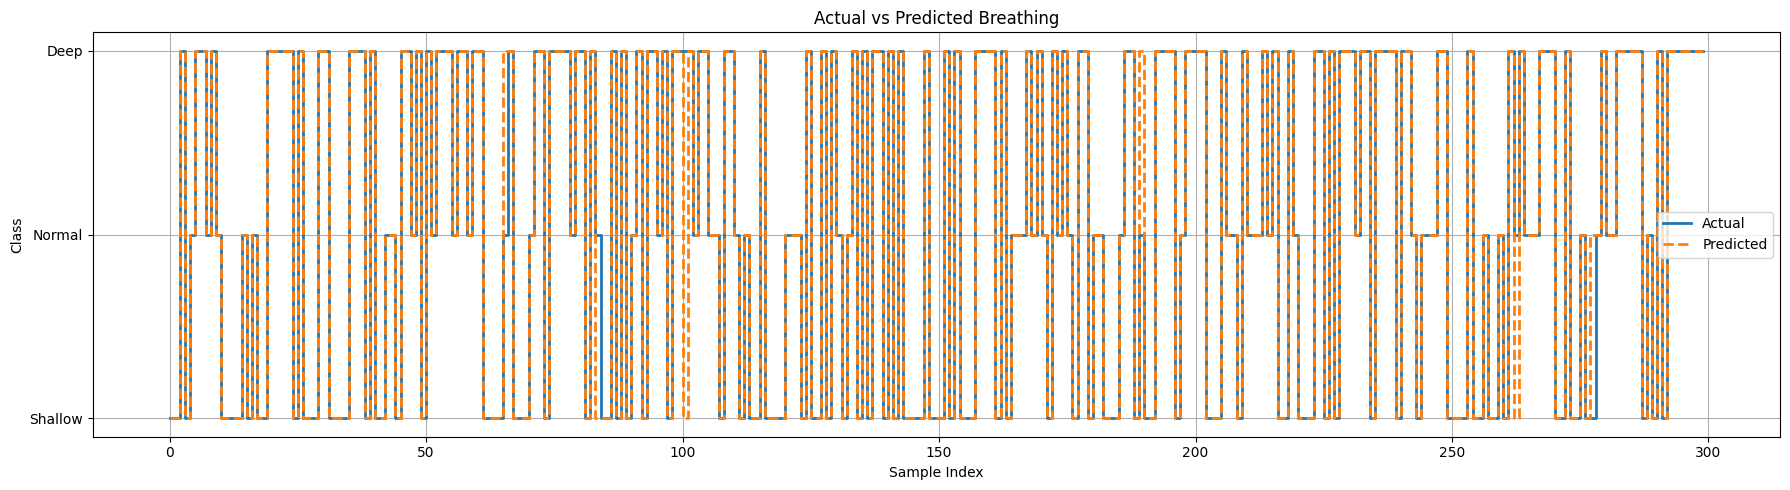

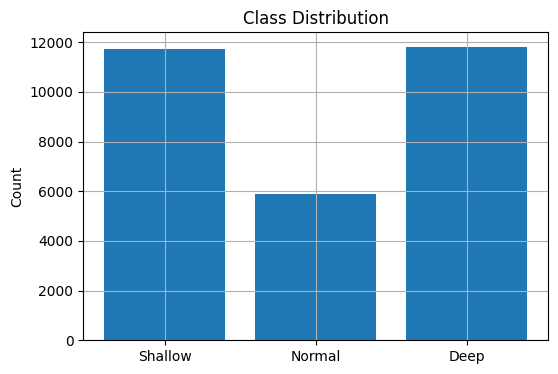

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import ConfusionMatrixDisplay
import seaborn as sns


plt.figure(figsize=(6,6))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=["Shallow", "Normal", "Deep"],
    cmap='Blues'
)
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()



feature_names = [
    "mean", "std", "max", "min",
    "amplitude", "gradient", "variance"
]

importances = model.feature_importances_

plt.figure(figsize=(10,5))
plt.bar(feature_names, importances)
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.grid(True)
plt.show()



plt.figure(figsize=(18,5))

n = 300

plt.step(range(n), y_test[:n], label="Actual", linewidth=2)
plt.step(range(n), y_pred[:n], label="Predicted",
         linestyle='dashed', linewidth=2)

plt.yticks([0,1,2], ["Shallow","Normal","Deep"])

plt.title("Actual vs Predicted Breathing")
plt.xlabel("Sample Index")
plt.ylabel("Class")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



unique, counts = np.unique(y, return_counts=True)

plt.figure(figsize=(6,4))
plt.bar(["Shallow","Normal","Deep"], counts)
plt.title("Class Distribution")
plt.ylabel("Count")
plt.grid(True)
plt.show()

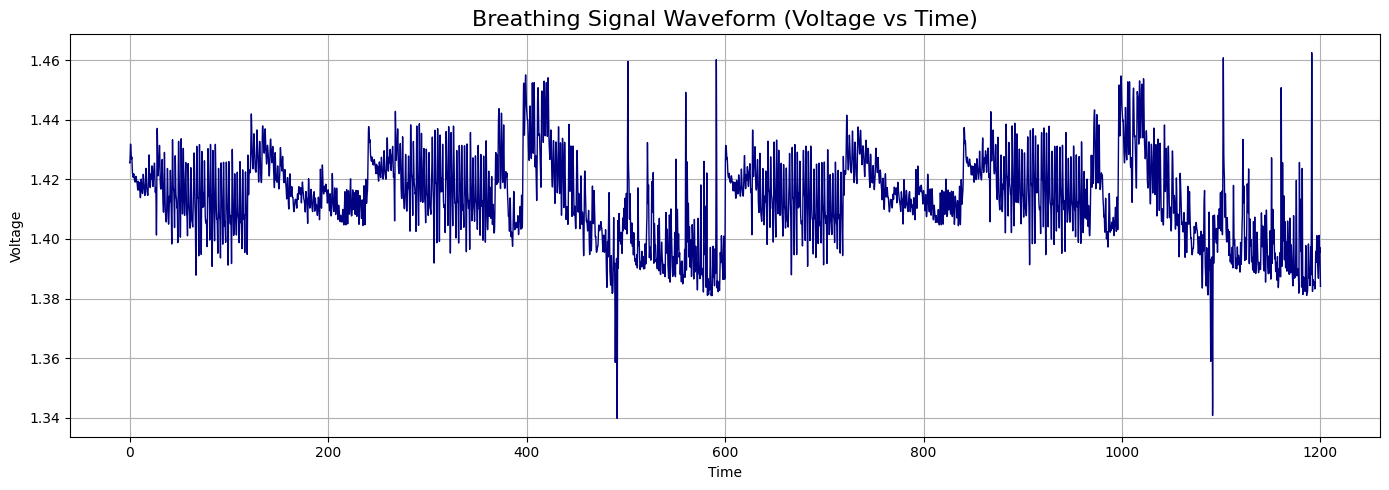

In [ ]:
plt.figure(figsize=(14,5))

df['Vout_filtered'] = low_pass_filter(df['Vout'])

plt.plot(df['time_seconds'], df['Vout_filtered'], color='navy', linewidth=1)

plt.title("Breathing Signal Waveform (Voltage vs Time)", fontsize=16)
plt.xlabel("Time")
plt.ylabel("Voltage")
plt.grid(True)

plt.tight_layout()
plt.show()

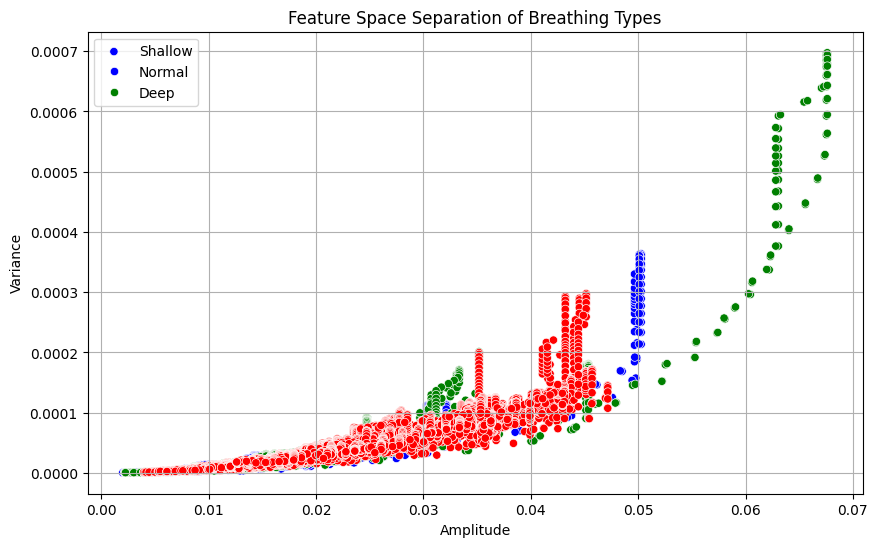

In [ ]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x=feature_df['amplitude'],
    y=feature_df['variance'],
    hue=y,
    palette=['blue','green','red']
)

plt.xlabel("Amplitude")
plt.ylabel("Variance")
plt.title("Feature Space Separation of Breathing Types")

plt.legend(labels=["Shallow","Normal","Deep"])

plt.grid(True)
plt.show()